In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE

In [33]:
# Load dataset
df = pd.read_csv("creditcard dataset.csv")

# EDA (Exploratory Data Analysis)

In [34]:
# ---------------------- Data Analysis ----------------------
print("Dataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

# Imbalanced Class Distrubition before SMOTE

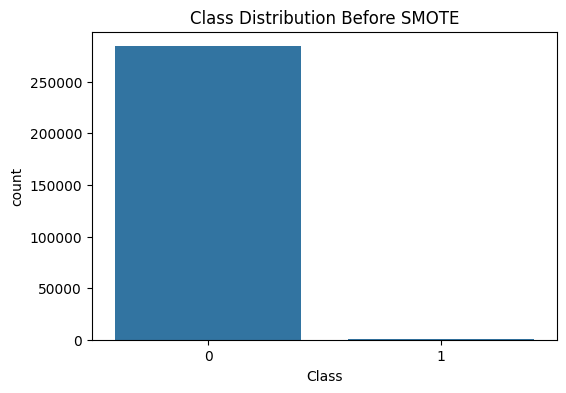

In [35]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution Before SMOTE')
plt.show()

<Figure size 1200x800 with 0 Axes>

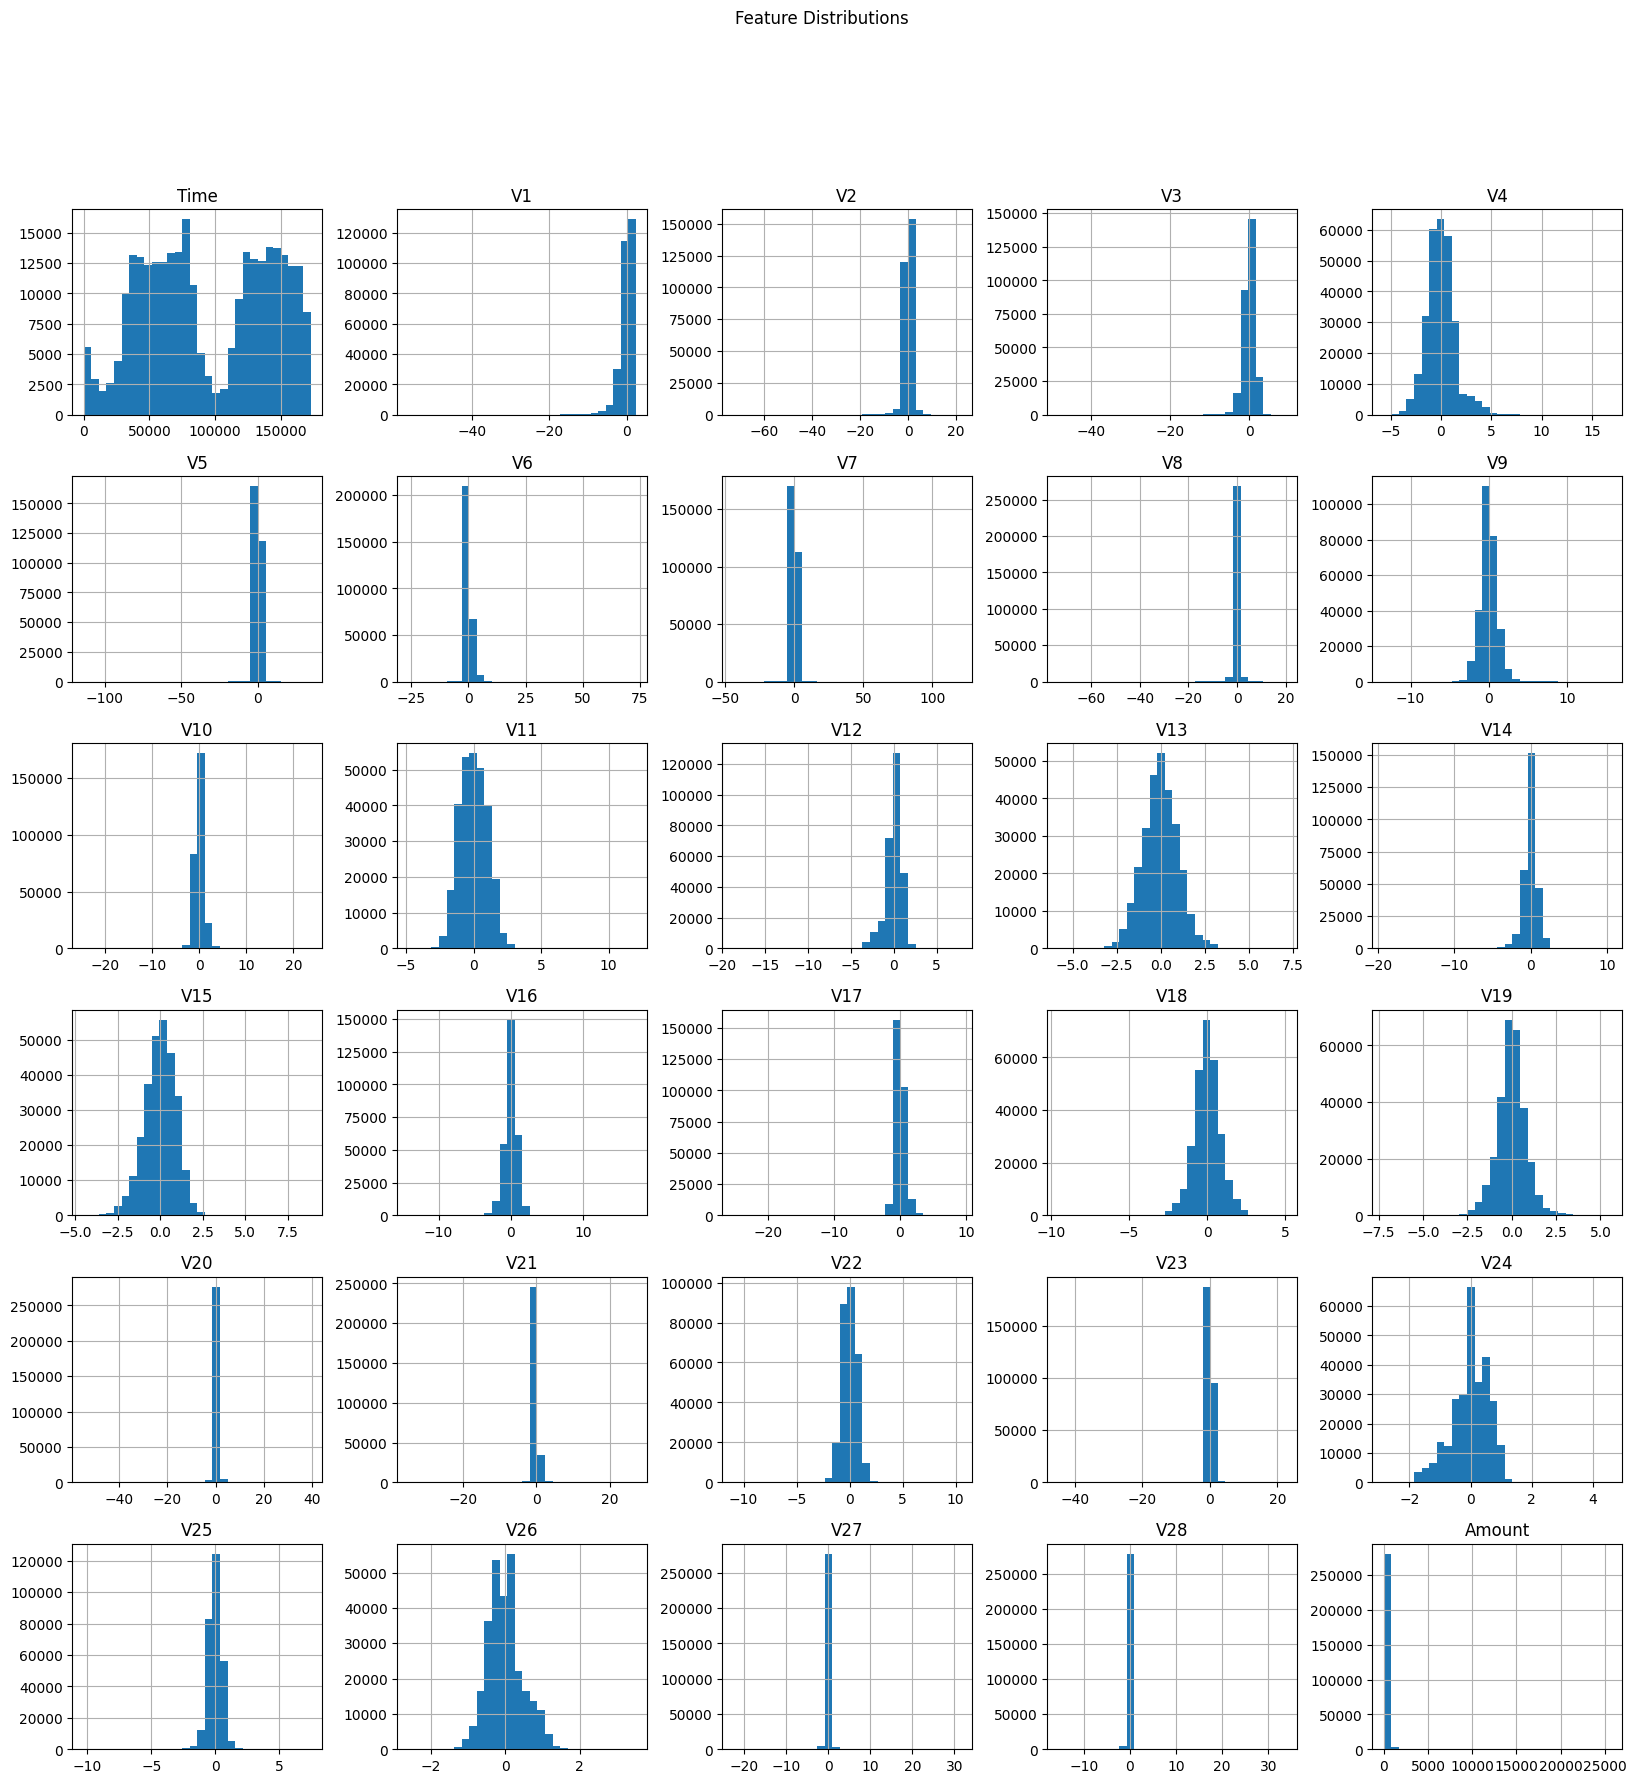

In [36]:
# Feature distributions
plt.figure(figsize=(12,8))
df.drop('Class', axis=1).hist(figsize=(20,20), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

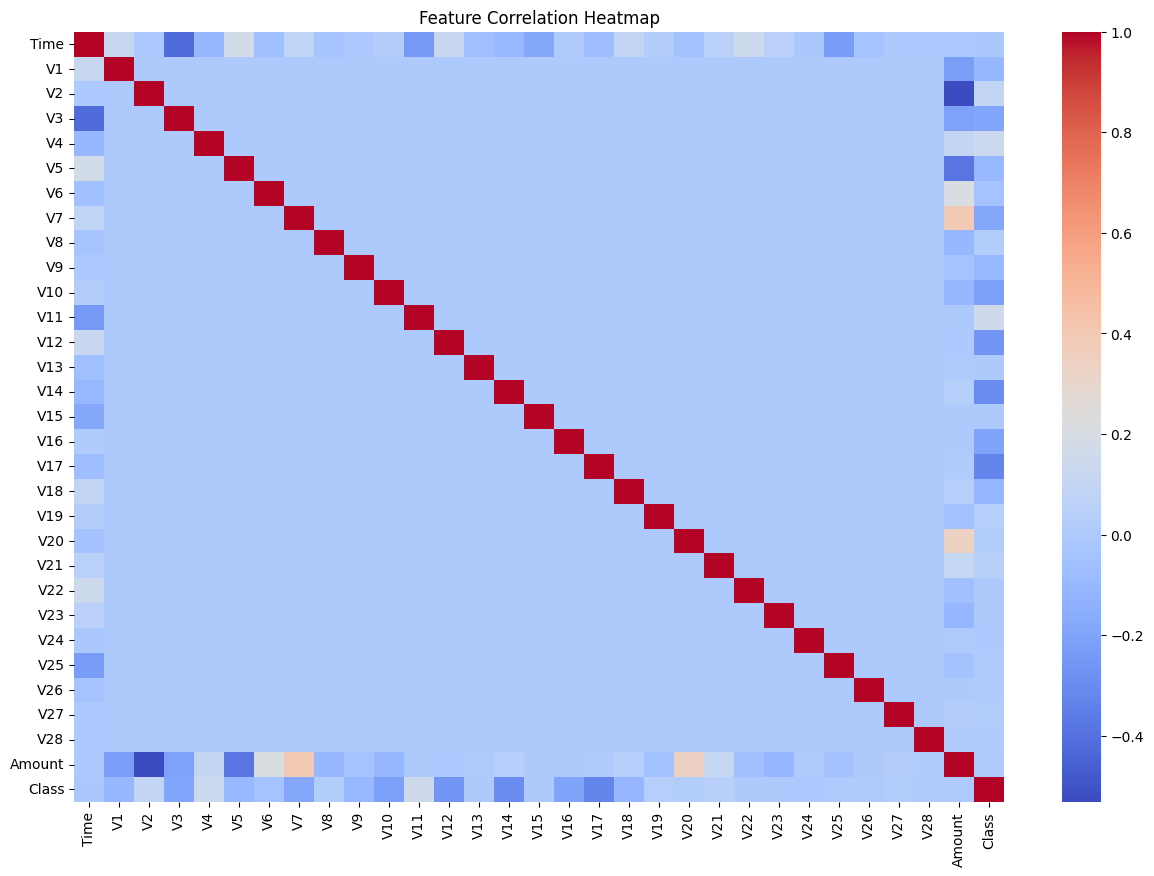

In [37]:
# Correlation heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

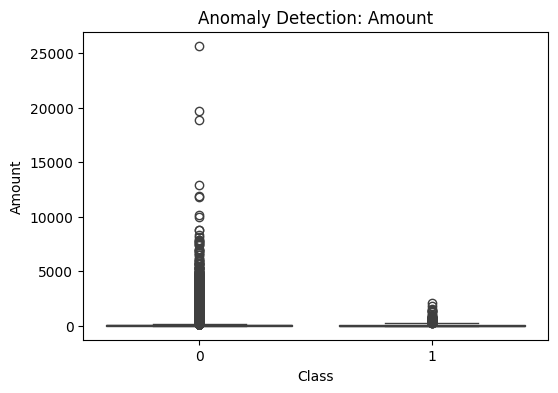

In [38]:
# Anomaly detection using boxplots
anomaly_features = ['Amount']
for feature in anomaly_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f'Anomaly Detection: {feature}')
    plt.show()

# Data Preprocessing

In [39]:
# ---------------------- Data Preprocessing ----------------------
from sklearn.preprocessing import StandardScaler

# Normalize 'Amount' column
df['Amount'] = StandardScaler().fit_transform(df[['Amount']])

# Drop 'Time' column if it exists
df = df.drop(columns=['Time'], errors='ignore')

df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


# Applying SMOTE for balanced class distribution

In [40]:
# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

In [41]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Balanced Class Distribution after SMOTE

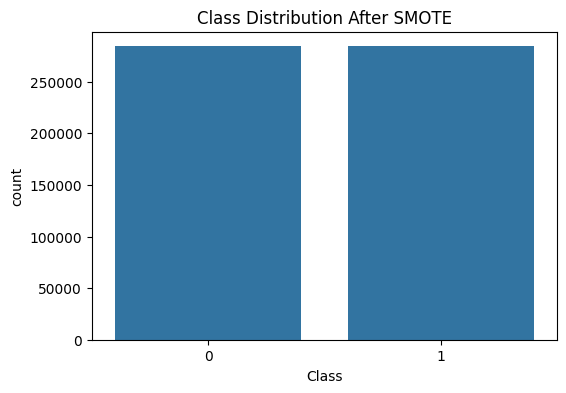

In [42]:
# Class distribution after SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title('Class Distribution After SMOTE')
plt.show()

# Splitting Test data and Train data

In [43]:
# ---------------------- Train-Test Split ----------------------
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Logistic Regression Model

In [44]:
# ---------------------- Logistic Regression ----------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [45]:
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     85149
           1       0.97      0.92      0.95     85440

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589



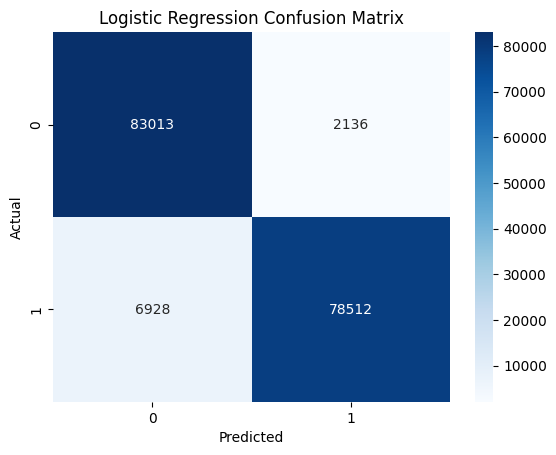

In [46]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

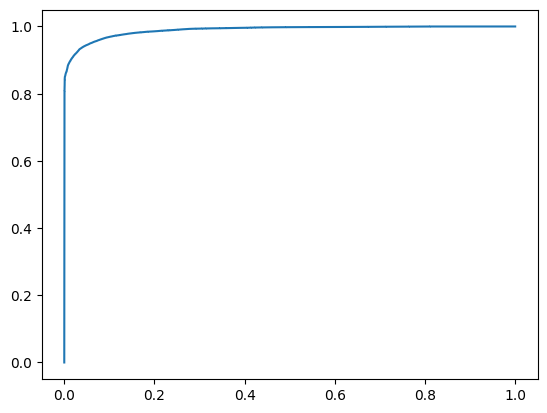

In [47]:
# ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = {:.2f})'.format(auc(fpr_lr, tpr_lr)))

# Random Forest Classifier

In [48]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [49]:
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85149
           1       1.00      1.00      1.00     85440

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589



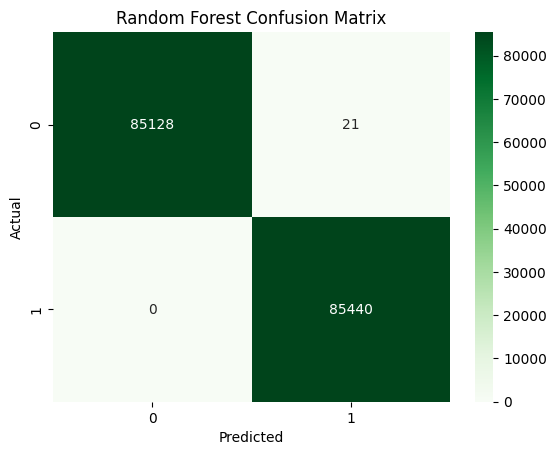

In [50]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve

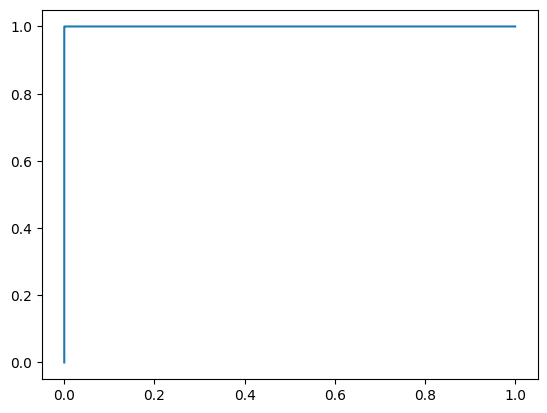

In [51]:
# ROC Curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(auc(fpr_rf, tpr_rf)))

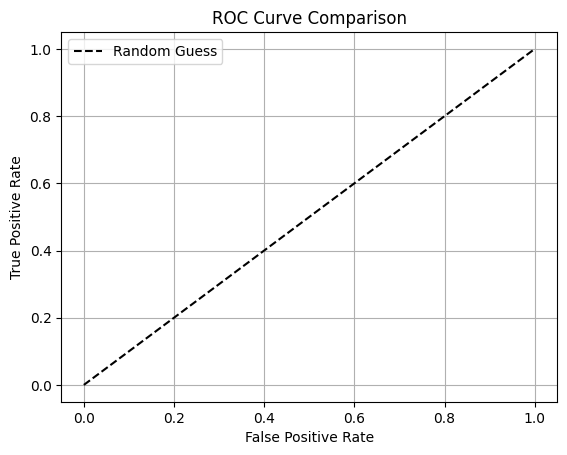

In [52]:
# Final ROC comparison
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance of Random Forest Classifier

In [53]:
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:]

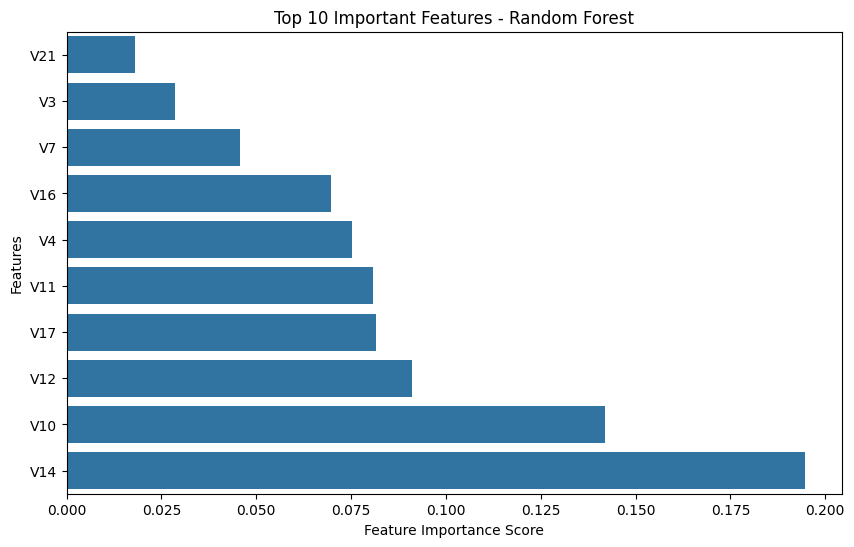

In [54]:
plt.figure(figsize=(10,6))
plt.title('Top 10 Important Features - Random Forest')
sns.barplot(x=importances[indices], y=features[indices])
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

# Best Model Check with F1 Score

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred),
    "ROC AUC": roc_auc_score(y_test, lr_probs)
}

# Random Forest metrics
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred),
    "ROC AUC": roc_auc_score(y_test, rf_probs)
}

# Compare and print
comparison_df = pd.DataFrame([lr_metrics, rf_metrics])
print(comparison_df)

# Best model based on F1 Score (you can choose any metric)
best_model = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
print(f"\n✅ Best Model: {best_model['Model']} with F1 Score = {best_model['F1 Score']:.4f}")


                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.946866   0.973515  0.918914  0.945427  0.989160
1        Random Forest  0.999877   0.999754  1.000000  0.999877  0.999993

✅ Best Model: Random Forest with F1 Score = 0.9999


# Best Model is Random Forest with F1 Score = 0.9999